# Sprint 4.3 - Comparing TLS Distributions with FastFuel-Data Models

In [23]:
# ------------------------
# IMPORTS
# ------------------------

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [24]:
# ------------------------
# SETUP & DATA LOADING
# ------------------------

# Load tree data
ff_data = pd.read_csv("./data/FF_treelist_all.csv")
field_data = pd.read_csv("./data/03_tree.csv")
tls_data = pd.read_csv("./data/NEW_TLS_treelist.csv")
ref_species = pd.read_csv("./data/REF_SPECIES.csv")
pft_codes = pd.read_csv("./data/FIATreeSpeciesCode_pft.csv")

In [25]:
# ------------------------
# CREATE FASTFUELS DATASET + DATA CLEANING
# ------------------------

# Map SPCD from species name
ref_species["scientific_name"] = ref_species["GENUS"] + " " + ref_species["SPECIES"]
name_to_spcd = dict(zip(ref_species["scientific_name"], ref_species["SPCD"]))
field_data["SPCD"] = field_data["tree_sp_scientific_name"].map(name_to_spcd)

# Join PFT codes
field_data = field_data.merge(ref_species[["SPCD", "GENUS"]], on="SPCD", how="left")
field_data = field_data.merge(pft_codes, on="SPCD", how="left")

# Rename for consistency
field_data["HT"] = field_data["tree_ht"]
field_data["DBH"] = field_data["tree_dbh"]
field_data["CBH"] = field_data["tree_htlcb"]

# Drop rows with missing labels or features
field_data = field_data.dropna(subset=["HT", "DBH", "CBH", "PFT", "GENUS", "SPCD"])

# Join on SPCD
ff_labeled = ff_data.merge(ref_species[["SPCD", "GENUS", "SPECIES"]], on="SPCD", how="left")
ff_labeled = ff_labeled.merge(pft_codes[["SPCD", "PFT"]], on="SPCD", how="left")

# Combine names
ff_labeled["SCI_NAME"] = ff_labeled["GENUS"] + " " + ff_labeled["SPECIES"]

# Select relevant features and targets
ff_labeled = ff_labeled[["SPCD", "GENUS", "SPECIES", "SCI_NAME", "PFT", "DIA", "HT", "CBH", "CR", "site_name"]]

# Rename for consistency with model input
ff_labeled = ff_labeled.rename(columns={
    "DIA": "DBH",
    "HT": "HT",
    "CBH": "CBH"
})

# Drop missing labels or features
ff_labeled = ff_labeled.dropna(subset=["DBH", "HT", "CBH", "PFT", "GENUS", "SPCD"])

# Encode site_name as categorical
ff_labeled["site_name"] = ff_labeled["site_name"].astype("category")
ff_labeled["site_name_cat"] = ff_labeled["site_name"].cat.codes

ff_labeled.head()

,SPCD,GENUS,SPECIES,SCI_NAME,PFT,DBH,HT,CBH,CR,site_name,site_name_cat
0,116,Pinus,jeffreyi,Pinus jeffreyi,Evergreen conifer,75.946,32.9184,23.04288,2.043188,ind,2
1,108,Pinus,contorta,Pinus contorta,Evergreen conifer,45.974,16.1544,4.84632,2.339576,ind,2
2,108,Pinus,contorta,Pinus contorta,Evergreen conifer,45.974,16.1544,4.84632,2.339576,ind,2
4,108,Pinus,contorta,Pinus contorta,Evergreen conifer,40.132,17.9832,13.48740,0.930155,ind,2
6,108,Pinus,contorta,Pinus contorta,Evergreen conifer,50.292,25.6032,8.96112,3.443150,ind,2


In [5]:
# ------------------------
# MODEL TRAINING FUNCTIONS
# ------------------------
def train_and_evaluate_rf(df, target, label_map=None):
    X = df[["HT", "DBH", "CBH", "CR", "site_name_cat"]]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"\n=== {target} RANDOM FOREST REPORT ===")
    if label_map:
        labels = sorted(y.unique())
        names = [label_map.get(l, f"{l}") for l in labels]
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        disp = ConfusionMatrixDisplay(cm, display_labels=names)
        disp.plot(xticks_rotation=90)
        plt.title(f"Confusion Matrix for {target} - Random Forest")
        plt.show()
    print(classification_report(y_test, y_pred))
    return model

def train_and_evaluate_logistic(df, target, label_map=None):
    X = df[["HT", "DBH", "CBH", "CR", "site_name_cat"]]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression(max_iter=1000, multi_class='auto', solver='lbfgs')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"\n=== {target} LOGISTIC REGRESSION REPORT ===")
    if label_map:
        labels = sorted(y.unique())
        names = [label_map.get(l, f"{l}") for l in labels]
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        disp = ConfusionMatrixDisplay(cm, display_labels=names)
        disp.plot(xticks_rotation=90)
        plt.title(f"Confusion Matrix for {target} - Logistic")
        plt.show()
    print(classification_report(y_test, y_pred))
    return model

def train_and_evaluate_adaboost(df, target, label_map=None):
    X = df[["HT", "DBH", "CBH", "CR", "site_name_cat"]]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = AdaBoostClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"\n=== {target} ADABOOST REPORT ===")
    if label_map:
        labels = sorted(y.unique())
        names = [label_map.get(l, f"{l}") for l in labels]
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        disp = ConfusionMatrixDisplay(cm, display_labels=names)
        disp.plot(xticks_rotation=90)
        plt.title(f"Confusion Matrix for {target} - AdaBoost")
        plt.show()
    print(classification_report(y_test, y_pred))
    return model


# Label mappings for readable confusion matrices
spcd_to_common = dict(zip(ref_species["SPCD"], ref_species["COMMON_NAME"]))
genus_map = dict(zip(ref_species["GENUS"], ref_species["GENUS"]))
pft_map = dict(zip(pft_codes["PFT"], pft_codes["PFT"]))


=== PFT RANDOM FOREST REPORT ===


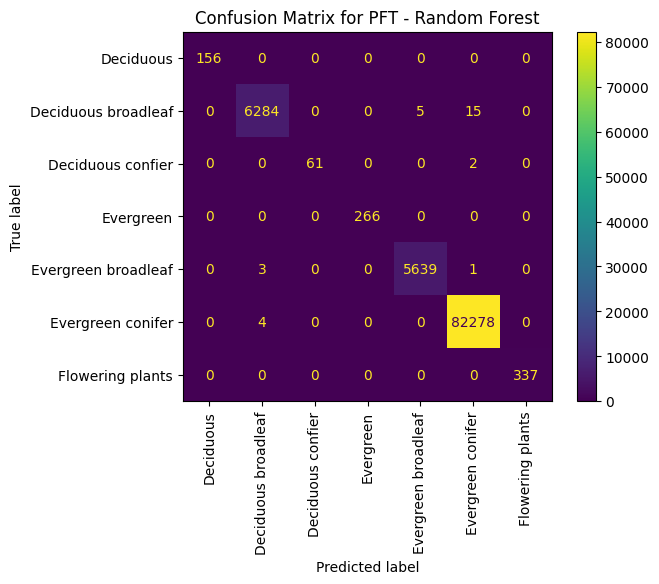

                     precision    recall  f1-score   support

          Deciduous       1.00      1.00      1.00       156
Deciduous broadleaf       1.00      1.00      1.00      6304
  Deciduous confier       1.00      0.97      0.98        63
          Evergreen       1.00      1.00      1.00       266
Evergreen broadleaf       1.00      1.00      1.00      5643
  Evergreen conifer       1.00      1.00      1.00     82282
   Flowering plants       1.00      1.00      1.00       337

           accuracy                           1.00     95051
          macro avg       1.00      0.99      1.00     95051
       weighted avg       1.00      1.00      1.00     95051


=== GENUS RANDOM FOREST REPORT ===
              precision    recall  f1-score   support

       Abies       1.00      1.00      1.00     15936
        Acer       1.00      0.99      1.00       344
    Aesculus       1.00      0.60      0.75        10
       Alnus       1.00      1.00      1.00         7
     Arbutus       

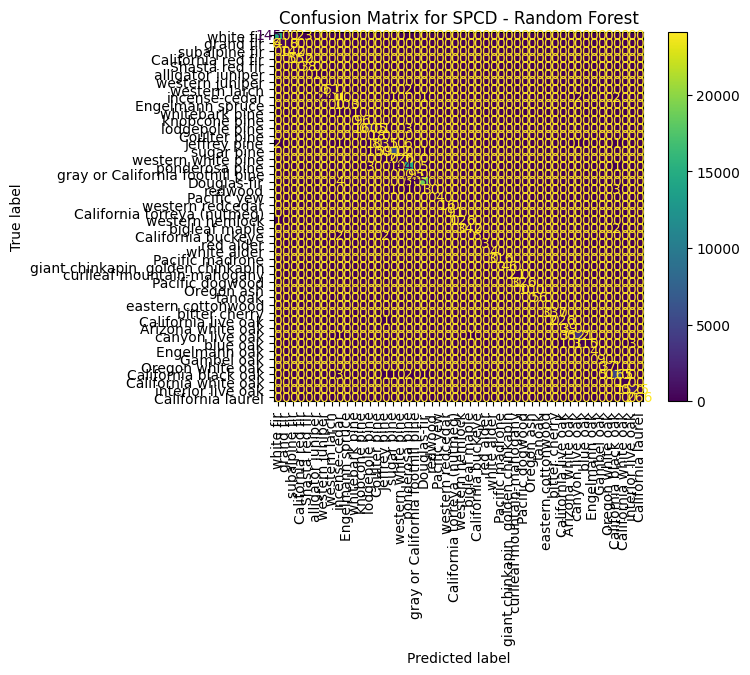

              precision    recall  f1-score   support

          15       1.00      1.00      1.00     14582
          17       1.00      0.99      1.00       622
          19       1.00      1.00      1.00       142
          20       1.00      1.00      1.00       552
          21       0.93      1.00      0.96        38
          63       1.00      1.00      1.00         1
          73       1.00      0.97      0.98        63
          81       1.00      1.00      1.00     24139
          93       1.00      1.00      1.00       103
         101       1.00      0.50      0.67         2
         103       1.00      1.00      1.00        96
         108       1.00      1.00      1.00      1609
         109       1.00      1.00      1.00        18
         116       0.99      0.98      0.99       848
         117       1.00      1.00      1.00      5914
         119       1.00      1.00      1.00       227
         122       1.00      1.00      1.00     14422
         127       1.00    

In [6]:
# ------------------------
# MODELING TASKS - RANDOM FOREST
# ------------------------
# Task 1: Predict PFT
pft_model_rf = train_and_evaluate_rf(ff_labeled, "PFT", pft_map)

# Task 2: Predict GENUS
genus_model_rf = train_and_evaluate_rf(ff_labeled, "GENUS")

# Task 3: Predict SPCD (Species)
species_model_rf = train_and_evaluate_rf(ff_labeled, "SPCD", spcd_to_common)

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== PFT LOGISTIC REGRESSION REPORT ===


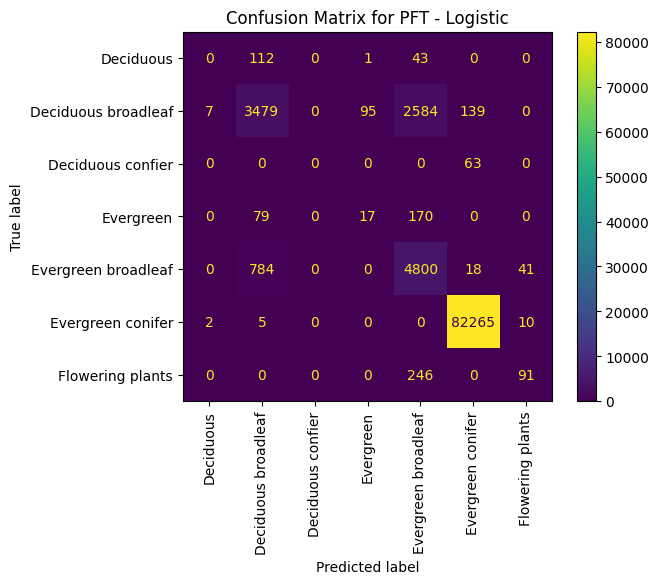

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                     precision    recall  f1-score   support

          Deciduous       0.00      0.00      0.00       156
Deciduous broadleaf       0.78      0.55      0.65      6304
  Deciduous confier       0.00      0.00      0.00        63
          Evergreen       0.15      0.06      0.09       266
Evergreen broadleaf       0.61      0.85      0.71      5643
  Evergreen conifer       1.00      1.00      1.00     82282
   Flowering plants       0.64      0.27      0.38       337

           accuracy                           0.95     95051
          macro avg       0.45      0.39      0.40     95051
       weighted avg       0.95      0.95      0.95     95051



/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== GENUS LOGISTIC REGRESSION REPORT ===


/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/l

              precision    recall  f1-score   support

       Abies       0.98      1.00      0.99     15936
        Acer       0.93      0.08      0.14       344
    Aesculus       0.00      0.00      0.00        10
       Alnus       0.00      0.00      0.00         7
     Arbutus       0.00      0.00      0.00       316
  Calocedrus       0.90      0.91      0.90     24139
 Cercocarpus       0.00      0.00      0.00        21
 Chrysolepis       0.00      0.00      0.00        46
      Cornus       0.00      0.00      0.00       326
    Fraxinus       0.00      0.00      0.00       100
   Juniperus       0.00      0.00      0.00         1
       Larix       0.00      0.00      0.00        63
 Lithocarpus       0.00      0.00      0.00        56
       Picea       0.00      0.00      0.00       103
       Pinus       1.00      0.95      0.97     23231
      Prunus       0.34      0.45      0.39       337
 Pseudotsuga       0.86      0.90      0.88     18598
     Quercus       0.86    

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== SPCD LOGISTIC REGRESSION REPORT ===


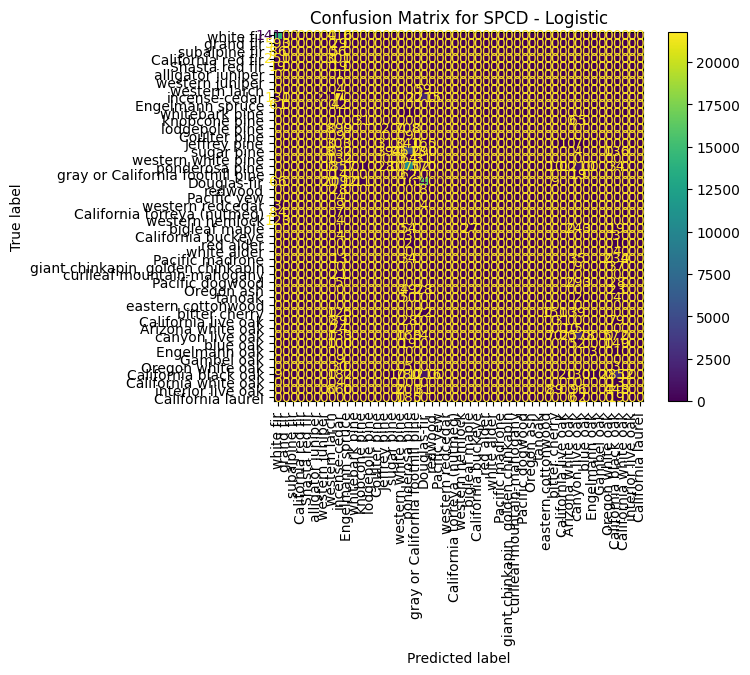

              precision    recall  f1-score   support

          15       0.91      0.97      0.94     14582
          17       0.00      0.00      0.00       622
          19       0.00      0.00      0.00       142
          20       0.00      0.00      0.00       552
          21       0.00      0.00      0.00        38
          63       0.00      0.00      0.00         1
          73       0.00      0.00      0.00        63
          81       0.72      0.90      0.80     24139
          93       0.00      0.00      0.00       103
         101       0.00      0.00      0.00         2
         103       0.72      0.32      0.45        96
         108       0.00      0.00      0.00      1609
         109       0.00      0.00      0.00        18
         116       0.31      0.04      0.07       848
         117       0.00      0.00      0.00      5914
         119       0.00      0.00      0.00       227
         122       0.59      0.74      0.66     14422
         127       0.00    

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
# ------------------------
# MODELING TASKS - LOGISTIC REG
# ------------------------
# Task 1: Predict PFT
pft_model_logistic = train_and_evaluate_logistic(ff_labeled, "PFT", pft_map)

# Task 2: Predict GENUS
genus_model_logistic = train_and_evaluate_logistic(ff_labeled, "GENUS")

# Task 3: Predict SPCD (Species)
species_model_logistic = train_and_evaluate_logistic(ff_labeled, "SPCD", spcd_to_common)


=== PFT ADABOOST REPORT ===


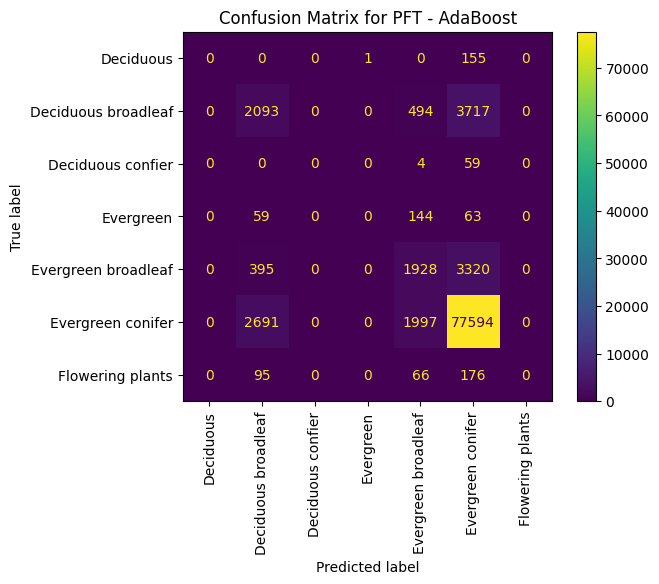

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                     precision    recall  f1-score   support

          Deciduous       0.00      0.00      0.00       156
Deciduous broadleaf       0.39      0.33      0.36      6304
  Deciduous confier       0.00      0.00      0.00        63
          Evergreen       0.00      0.00      0.00       266
Evergreen broadleaf       0.42      0.34      0.38      5643
  Evergreen conifer       0.91      0.94      0.93     82282
   Flowering plants       0.00      0.00      0.00       337

           accuracy                           0.86     95051
          macro avg       0.25      0.23      0.24     95051
       weighted avg       0.84      0.86      0.85     95051


=== GENUS ADABOOST REPORT ===


/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       Abies       0.44      0.37      0.41     15936
        Acer       0.00      0.00      0.00       344
    Aesculus       0.00      0.00      0.00        10
       Alnus       0.00      0.00      0.00         7
     Arbutus       0.00      0.00      0.00       316
  Calocedrus       0.60      0.43      0.50     24139
 Cercocarpus       0.00      0.00      0.00        21
 Chrysolepis       0.00      0.00      0.00        46
      Cornus       0.00      0.00      0.00       326
    Fraxinus       0.00      0.00      0.00       100
   Juniperus       0.00      0.00      0.00         1
       Larix       0.00      0.00      0.00        63
 Lithocarpus       0.00      0.00      0.00        56
       Picea       0.00      0.00      0.00       103
       Pinus       0.52      0.44      0.48     23231
      Prunus       0.00      0.00      0.00       337
 Pseudotsuga       0.34      0.60      0.43     18598
     Quercus       0.42    

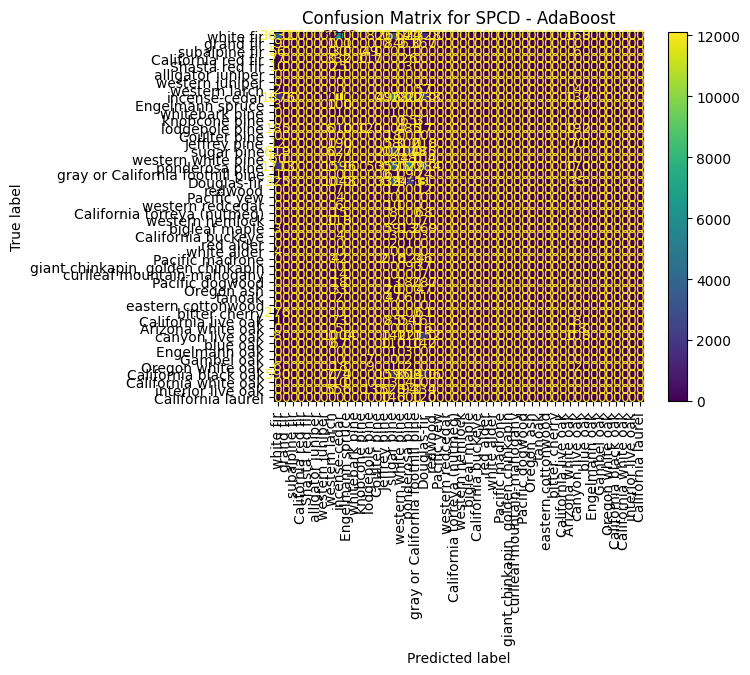

              precision    recall  f1-score   support

          15       0.38      0.25      0.30     14582
          17       0.00      0.00      0.00       622
          19       0.00      0.00      0.00       142
          20       0.00      0.00      0.00       552
          21       0.00      0.00      0.00        38
          63       0.00      0.00      0.00         1
          73       0.00      0.00      0.00        63
          81       0.47      0.50      0.49     24139
          93       0.00      0.00      0.00       103
         101       0.00      0.00      0.00         2
         103       0.00      0.00      0.00        96
         108       0.37      0.07      0.12      1609
         109       0.00      0.00      0.00        18
         116       0.00      0.00      0.00       848
         117       0.10      0.35      0.16      5914
         119       0.00      0.00      0.00       227
         122       0.33      0.35      0.34     14422
         127       0.00    

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
# ------------------------
# MODELING TASKS - ADABOOST
# ------------------------
# Task 1: Predict PFT
pft_model_adaboost = train_and_evaluate_adaboost(ff_labeled, "PFT", pft_map)

# Task 2: Predict GENUS
genus_model_adaboost = train_and_evaluate_adaboost(ff_labeled, "GENUS")

# Task 3: Predict SPCD (Species)
species_model_adaboost = train_and_evaluate_adaboost(ff_labeled, "SPCD", spcd_to_common)

In [26]:
# ------------------------
# APPLY TO TLS DATA
# ------------------------

# filtering necessary data
tls_data = tls_data[['HT', 'DIA', 'site_name_cat', 'CBH', 'CR']]
tls_data["DBH"] = tls_data["DIA"]

# Predict using trained models -- Forest
tls_data["PFT_pred_Forest"] = pft_model_rf.predict(tls_data[["HT", "DBH", "CBH", 'CR', 'site_name_cat']].fillna(0))
tls_data["GENUS_pred_Forest"] = genus_model_rf.predict(tls_data[["HT", "DBH", "CBH",'CR', 'site_name_cat']].fillna(0))
tls_data["SPCD_pred_Forest"] = species_model_rf.predict(tls_data[["HT", "DBH", "CBH", 'CR','site_name_cat']].fillna(0))
print("Random Forest Classifier Done Predicting!")

# Predict using trained models -- Logistic
tls_data["PFT_pred_Logistic"] = pft_model_logistic.predict(tls_data[["HT", "DBH", "CBH",'CR','site_name_cat']].fillna(0))
tls_data["GENUS_pred_Logistic"] = genus_model_logistic.predict(tls_data[["HT", "DBH", "CBH",'CR', 'site_name_cat']].fillna(0))
tls_data["SPCD_pred_Logistic"] = species_model_logistic.predict(tls_data[["HT", "DBH", "CBH",'CR', 'site_name_cat']].fillna(0))
print("Logistic Regression Classifier Done Predicting!")

# Predict using trained models -- AdaBoost
tls_data["PFT_pred_Adaboost"] = pft_model_adaboost.predict(tls_data[["HT", "DBH", "CBH",'CR', 'site_name_cat']].fillna(0))
tls_data["GENUS_pred_Adaboost"] = genus_model_adaboost.predict(tls_data[["HT", "DBH", "CBH",'CR','site_name_cat']].fillna(0))
tls_data["SPCD_pred_Adaboost"] = species_model_adaboost.predict(tls_data[["HT", "DBH", "CBH",'CR','site_name_cat']].fillna(0))
print("AdaBoost Classifier Done Predicting!")

Random Forest Classifier Done Predicting!
Logistic Regression Classifier Done Predicting!
AdaBoost Classifier Done Predicting!


In [30]:
# ------------------------
# DISTRIBUTION COMPARISON -- PFT
# ------------------------

# Get proportion distributions for each method
forest_dist = tls_data["PFT_pred_Forest"].value_counts(normalize=True)
logistic_dist = tls_data["PFT_pred_Logistic"].value_counts(normalize=True)
adaboost_dist = tls_data["PFT_pred_Adaboost"].value_counts(normalize=True)
observed_dist = field_data["PFT"].value_counts(normalize=True)

# Combine into a single DataFrame
pft_dist_df = pd.DataFrame({
    "Random Forest": forest_dist,
    "Logistic": logistic_dist,
    "AdaBoost": adaboost_dist,
    "Observed (Field)": observed_dist
})

pft_dist_df = pft_dist_df.fillna(0)
pft_dist_df = pft_dist_df.sort_values("Observed (Field)", ascending=False)
pft_dist_df = pft_dist_df.applymap(lambda x: f"{x*100:.2f}%")
pft_dist_df

/tmp/ipykernel_363/980180014.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pft_dist_df = pft_dist_df.applymap(lambda x: f"{x*100:.2f}%")


,Random Forest,Logistic,AdaBoost,Observed (Field)
Evergreen conifer,80.03%,68.31%,81.48%,71.92%
Evergreen broadleaf,12.66%,11.65%,12.23%,20.22%
Deciduous broadleaf,6.73%,17.29%,6.22%,6.99%
Deciduous,0.58%,2.10%,0.00%,0.87%
Evergreen,0.00%,0.29%,0.07%,0.00%
Flowering plants,0.00%,0.36%,0.00%,0.00%


In [31]:
# ------------------------
# DISTRIBUTION COMPARISON -- GENUS
# ------------------------

# Get proportion distributions for each method
forest_dist = tls_data["GENUS_pred_Forest"].value_counts(normalize=True)
logistic_dist = tls_data["GENUS_pred_Logistic"].value_counts(normalize=True)
adaboost_dist = tls_data["GENUS_pred_Adaboost"].value_counts(normalize=True)
observed_dist = field_data["GENUS"].value_counts(normalize=True)

# Combine into a single DataFrame
genus_dist_df = pd.DataFrame({
    "Random Forest": forest_dist,
    "Logistic": logistic_dist,
    "AdaBoost": adaboost_dist,
    "Observed (Field)": observed_dist
})

genus_dist_df = genus_dist_df.fillna(0)
genus_dist_df = genus_dist_df.sort_values("Observed (Field)", ascending=False)
genus_dist_df = genus_dist_df.applymap(lambda x: f"{x*100:.2f}%")
genus_dist_df

/tmp/ipykernel_363/4883559.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  genus_dist_df = genus_dist_df.applymap(lambda x: f"{x*100:.2f}%")


,Random Forest,Logistic,AdaBoost,Observed (Field)
Quercus,20.04%,27.86%,15.12%,24.44%
Calocedrus,9.84%,17.73%,8.18%,24.26%
Abies,13.89%,13.39%,15.99%,22.07%
Pinus,34.01%,17.37%,27.93%,19.06%
Pseudotsuga,20.26%,20.77%,32.78%,6.24%
Arbutus,0.07%,0.00%,0.00%,2.72%
Populus,0.00%,0.00%,0.00%,0.75%
Sequoiadendron,0.00%,0.00%,0.00%,0.29%
Salix,0.00%,0.00%,0.00%,0.12%
Acer,1.09%,1.01%,0.00%,0.06%


In [35]:
# ------------------------
# DISTRIBUTION COMPARISON -- SPECIES
# ------------------------

# Get proportion distributions for each method
forest_dist = tls_data["SPCD_pred_Forest"].value_counts(normalize=True)
logistic_dist = tls_data["SPCD_pred_Logistic"].value_counts(normalize=True)
adaboost_dist = tls_data["SPCD_pred_Adaboost"].value_counts(normalize=True)
observed_dist = field_data["SPCD"].value_counts(normalize=True)
species = field_data["tree_sp_scientific_name"]

# Combine into a single DataFrame
species_dist_df = pd.DataFrame({
    "Random Forest": forest_dist,
    "Logistic": logistic_dist,
    "AdaBoost": adaboost_dist,
    "Observed (Field)": observed_dist
})

species_dist_df = species_dist_df.fillna(0)
species_dist_df = species_dist_df.sort_values("Observed (Field)", ascending=False)
species_dist_df = species_dist_df.applymap(lambda x: f"{x*100:.2f}%")
species_dist_df["species_name"] = species
species_dist_df

/tmp/ipykernel_363/3642494428.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  species_dist_df = species_dist_df.applymap(lambda x: f"{x*100:.2f}%")


,Random Forest,Logistic,AdaBoost,Observed (Field),species_name
81.0,13.46%,22.87%,21.13%,24.26%,Calocedrus decurrens
15.0,11.36%,13.53%,9.77%,19.47%,NaN
801.0,7.67%,2.68%,0.00%,16.35%,Quercus douglasii
108.0,6.30%,0.07%,0.07%,7.51%,Calocedrus decurrens
116.0,1.59%,0.14%,0.00%,6.82%,Calocedrus decurrens
202.0,22.14%,19.25%,2.46%,6.24%,Calocedrus decurrens
818.0,6.01%,22.36%,0.00%,4.16%,Quercus agrifolia
122.0,18.81%,14.25%,22.79%,3.12%,Calocedrus decurrens
361.0,0.14%,0.00%,0.00%,2.72%,Pinus jeffreyi
20.0,0.94%,1.01%,0.00%,2.60%,Calocedrus decurrens
